In [ ]:
# !pip install numpyro
# !pip install jax

Restructure JSON files

In [1]:
import numpy as np
import json
from collections import OrderedDict, defaultdict
from confdl import reformat_json, Vocabulary, Dataset

## Load and preprocess

In [2]:
experiment = 'ambig_qa_multiple_qas_llama-3b-instruct_100_0'
input_file = f"data/{experiment}.json"
keep = {
    'human_judge1', 
    'human_judge2', 
    'llm_as_judge_gpt-5.4-mini', 
    'exact_match', 
    'rouge_l/0.1', 
    'bert_score/0.3', 
    'bert_score/0.8', 
    'bert_score/0.9', 
    'log_likelihood_seq', 
    'log_likelihood_token', 
    'entropy', 
    'semantic_entropy', 
    'semantic_confidence', 
    'verbalised_confidence', 
    'p_true'
}
jrows, srows = reformat_json(
    input_file,
    # reverse={'entropy', 'semantic_entropy'},
    keep=keep
)

In [3]:
ds = Dataset(system_rows=srows, judge_rows=jrows, standardize=True)
ds.I.shape, ds.S.shape, ds.X.shape, ds.J.shape, ds.Y.shape

((4900,), (4900,), (4900,), (4900,), (4900,))

In [4]:
ds.sys2id.objects

['entropy',
 'semantic_entropy',
 'semantic_confidence',
 'log_likelihood_seq',
 'log_likelihood_token',
 'p_true',
 'verbalised_confidence']

In [5]:
ds.judge2id.objects

['human_judge1',
 'exact_match',
 'rouge_l/0.1',
 'bert_score/0.3',
 'bert_score/0.8',
 'bert_score/0.9',
 'llm_as_judge_gpt-5.4-mini']

In [6]:
np.array([j_name.startswith('human') for j_name in ds.judge2id.objects])

array([ True, False, False, False, False, False, False])

In [7]:
len(ds.item2id), len(ds.sys2id), len(ds.judge2id)

(100, 7, 7)

In [8]:
ds.X.mean(), ds.X.std()

(-2.6101569885064903e-17, 0.5)

# BDA

* $n$ indexes one of $N$ observations
* $i_n$ is the item id (i.e., a prompt-response pair in the dataset)
* $s_n$ is the system id
* $x_n$ is the confidence score assigned by system
* $j_n$ is the judge  id
* $y_n$ is the label produced by the judge/annotator

Confidence scores are not all between 0 and 1 and are not comparable across items, so we learn a latent mapping:

$z_{n} = \mu + \rho x_n + b_{s_n} + w_{s_n}  x_n + c_{j_n} + m_{j_n}  x_{n}$

where
* $\mu$ and $\rho$ are global parameters (all observations share; they capture a property of the distribution of items)
* $b, w$ are parameters of the systems
* $c, m$ are parameters of the judges

And then 

$y_n|x_n \sim \operatorname{Bernoulli}(\operatorname{sigmoid}(z_n))$


This is what the tall representation looks like:

```
Observation Item S      A     X     Y
1           1    verbc  h1    0.2   1
2           1    verbc  gpt   0.2   1
3           2    SE     h1    -1.2  0
4           2    SE     gpt   -1.2  1
```



In [9]:
import json
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.special as jsp 
import jax.nn as jnn
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt

In [10]:
def model(y, x, mask, system, judge, oracle, num_items, num_judges, num_systems):
    """
    N is number of observations.
    
    y: (N,) labels
    x: (N,) confidence scores 
    mask: (N,) use it to mask the likelihood function (eg, to handle missing data)
    system: (N,) system ids
    judge: (N,) judge ids
    oracle: (J,) one flag per judge, use True if Oracle
    num_items: number of prompt-response pairs in the dataset
    num_judges: number of judges
    num_systems: number of systems (uncertainty quantifiers)
    """

    b0 = numpyro.sample("b0", dist.Normal(0., 2.))
    w0 = numpyro.sample("w0", dist.Normal(0., 2.))
    
    with numpyro.plate("systems", num_systems):
        bs = numpyro.sample("bs", dist.Normal(0., 2.))
        ws = numpyro.sample("ws", dist.Normal(0., 2.))
    
    with numpyro.plate("judges", num_judges):        
        bj = numpyro.sample("bj", dist.Normal(0., 2.))
        wj = numpyro.sample("wj", dist.Normal(0., 2.))

        bj = jnp.where(oracle, b0, b0 + bj)
        wj = jnp.where(oracle, w0, w0 + wj)

    # with numpyro.plate("j_level", num_judges, dim=-2):        
    #     with numpyro.plate("s_level", num_systems, dim=-1):
    #         w = numpyro.sample("w", dist.Normal(0., 2.))

    #with numpyro.plate("items", num_items):
        # Probability that z_i is True
        # [N]        
    # z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[judge, system] * x)
    #z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[system] * x)

    z0 = numpyro.deterministic("z0", b0 + w0 * x)
    zs = numpyro.deterministic("zs", bs[system] + ws[system] * x)
    zj = numpyro.deterministic("zj", bs[judge] + wj[judge] * x)
    z = numpyro.deterministic("z", zs + zj)

    theta = numpyro.deterministic("theta", jax.nn.sigmoid(z))
    
    numpyro.sample(
        "obs",
        dist.Bernoulli(theta).mask(mask),
        obs=y
    )

# Inference

In [11]:
from numpyro.infer import MCMC, NUTS
from jax import random

NUM_CHAINS = 1
numpyro.set_host_device_count(NUM_CHAINS)

In [12]:
kernel = NUTS(model)

mcmc = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=2000,
    num_chains=2
)

/var/folders/5n/kqrxk4_d27342m7xqqjhg42c0000gn/T/ipykernel_39202/1101456103.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


In [13]:
rng_key = random.PRNGKey(0)

mcmc.run(
    rng_key,
    y=ds.Y,
    x=ds.X,
    mask=np.ones_like(ds.Y),
    judge=ds.J,
    system=ds.S,
    oracle=np.array([j_name.startswith('human') for j_name in ds.judge2id.objects]),
    num_items=len(ds.item2id),
    num_judges=len(ds.judge2id),
    num_systems=len(ds.sys2id),    
)

sample: 100%|█| 3000/3000 [00:26<00:00, 113.56it/s, 63 steps of size 8.84e-02. a
sample: 100%|█| 3000/3000 [00:28<00:00, 106.47it/s, 63 steps of size 8.54e-02. a


Ideally: `r_hat` is close to 1 and we have 0 divergences.

In [14]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        b0     -0.05      2.02     -0.03     -3.51      3.09   4609.54      1.00
     bj[0]     -0.01      2.04     -0.03     -3.14      3.39   4084.07      1.00
     bj[1]      0.05      2.00      0.05     -2.99      3.51   4443.38      1.00
     bj[2]      0.03      2.00      0.02     -3.37      3.11   3809.04      1.00
     bj[3]     -0.01      1.99     -0.02     -3.16      3.35   4783.24      1.00
     bj[4]     -0.01      2.03     -0.03     -3.28      3.34   5079.39      1.00
     bj[5]     -0.03      2.03     -0.04     -3.06      3.61   5093.05      1.00
     bj[6]     -0.06      1.98     -0.07     -3.46      3.09   4158.41      1.00
     bs[0]      0.18      0.05      0.18      0.09      0.27   4981.62      1.00
     bs[1]     -1.33      0.07     -1.33     -1.45     -1.21   4266.54      1.00
     bs[2]     -0.39      0.06     -0.39     -0.48     -0.30   4263.12      1.00
     bs[3]      1.33      0

In [15]:
posterior_samples = mcmc.get_samples(group_by_chain=False)
print("posterior samples shapes:")
for k, v in posterior_samples.items():
    print(k, v.shape)

posterior samples shapes:
b0 (4000,)
bj (4000, 7)
bs (4000, 7)
theta (4000, 4900)
w0 (4000,)
wj (4000, 7)
ws (4000, 7)
z (4000, 4900)
z0 (4000, 4900)
zj (4000, 4900)
zs (4000, 4900)


Oracle parameters

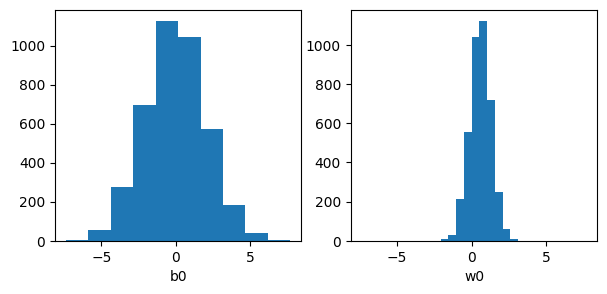

In [16]:
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(7, 3))
_ = axs[0].hist(posterior_samples['b0'])
_ = axs[0].set_xlabel("b0")
_ = axs[1].hist(posterior_samples['w0'])
_ = axs[1].set_xlabel("w0")

System parameters

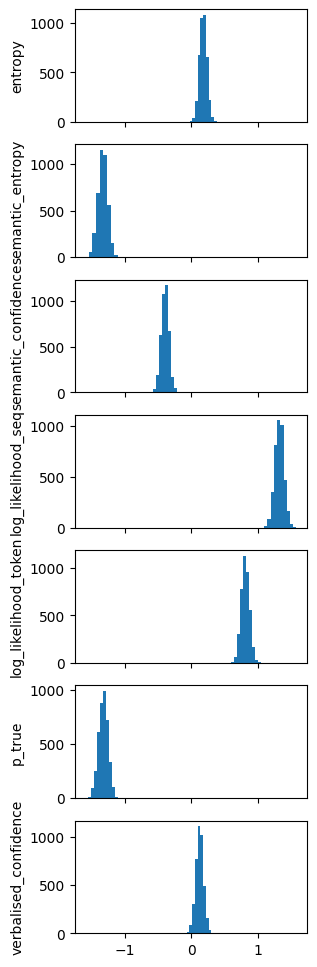

In [17]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(3,12))

for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['bs'][:,s])
    axs[s].set_ylabel(system)

In [18]:
# fig, axs = plt.subplots(len(ds.judge2id), 1, sharex=True, figsize=(3,12))

# for j, judge in enumerate(ds.judge2id.objects):
#     axs[j].hist(posterior_samples['bj'][:,j])
#     axs[j].set_ylabel(judge)

In [19]:
# fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id), sharex=True, figsize=(16,16))
# for j, judge in enumerate(ds.judge2id.objects):
#     for s, system in enumerate(ds.sys2id.objects):
#         axs[s, j].hist(posterior_samples['w'][:,j, s])
#         axs[s, 0].set_ylabel(system)
#         axs[0, j].set_title(judge)

The slopes will capture a predictive association between the confidence score and the judge. A positive slope means that the confidence score is a useful predictor of the judgments.

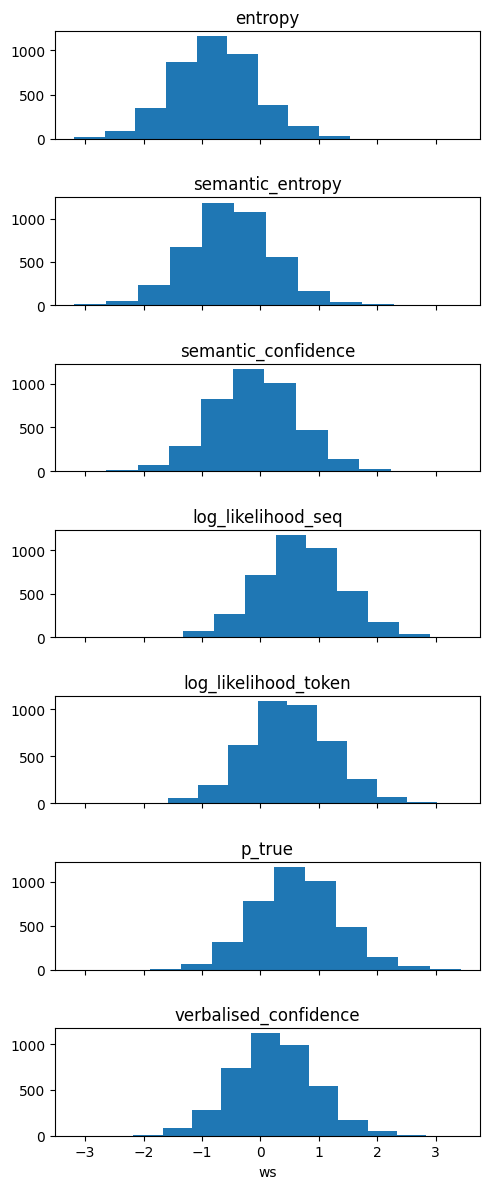

In [20]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(5,12))
for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['ws'][:,s])
    axs[s].set_title(system)
    axs[-1].set_xlabel("ws")

fig.tight_layout(h_pad=2, w_pad=2)

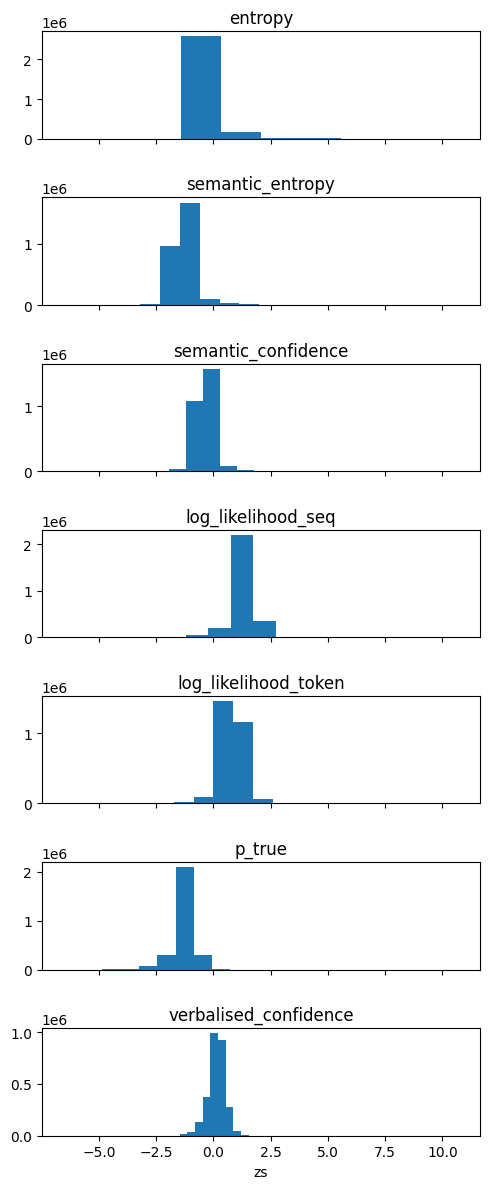

In [22]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(5,12))
for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['zs'][:,ds.S == s].flatten())
    axs[s].set_title(system)
    axs[-1].set_xlabel("zs")

fig.tight_layout(h_pad=2, w_pad=2)

In [23]:
# fig, axs = plt.subplots(len(ds.judge2id) - 1, 1, sharex=True, figsize=(5,12))
# for j, judge in enumerate(ds.judge2id.objects):
#     if j == 0:
#         continue
#     axs[j-1].hist(posterior_samples['zj'][:,j] - posterior_samples['zj'][:,0])
#     axs[j-1].set_title(judge)
#     axs[-1].set_xlabel("zj - z0")

# fig.tight_layout(h_pad=2, w_pad=2)

In [24]:
# # fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id), sharex=True, figsize=(12,12))
# for j, judge in enumerate(ds.judge2id.objects):
#     for s, system in enumerate(ds.sys2id.objects):
#         print(judge, system, (posterior_samples['w'][:,j, s] > 0.).mean())        

# Detailed Analysis

Now we use posterior confidence (that is, $\operatorname{sigmoid}(z_i)$) as a quantity that can be compared across systems and judges. 

We analyse judges in terms of how their predictions compared to a trusted judge (an oracle). When the judge is right (correct) its predictions are TN or TP. When the judge is wrong (incorrect) its predictions are FN or FP. When the judge is right, we collect good data for evaluation of the uncertainty quantifier that mediate our decisions (via selective generation, AUROC, etc), but when the judge is wrong we distort the evaluation results. Unfortunately, the ways in which a judge can be wrong can correlate with the ways in which confidence distributes leading to unjustified penalties and rewards that do not cancel each other. Here we seek to analyse precisely that.

We plot confidence against (TN, TP) and (FN, FP). We colour-code interesting regions of the plot, in particular, regions corresponding to incorrect judgements (FN and FP). When confidence is high a selective generator will commit to a response, when confidence is low a selective generator will refrain from responding. If we pair these two situations with FN and FP, we identify: unfair penalties (FP and low confidence; FN and high confidence) and unfair rewards (FP and high confidence; FN and low confidence). These are shown as red and green regions, respectively, in the plot.

In [25]:
import pandas as pd

In [26]:
# I use median because distributions over (0, 1) tend to be skewed
# but mean would be fine too
posterior_confidence = np.median(posterior_samples['theta'], 0)

We can store our dataset (in tall representation) and posterior confidences and work on any kind of analysis we want in some other notebook.

In [27]:
!mkdir -p inferences

/opt/homebrew/Cellar/python@3.9/3.9.15/Frameworks/Python.framework/Versions/3.9/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [31]:
import pickle

# with open(f"inferences/{experiment}.pickle", 'wb') as handle:
#     pickle.dump({'ds': ds, 'posterior_confidence': posterior_confidence}, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [32]:
# # Store the confidences in a json
# confs = []
# unique = set()
# for i, s, x, p in zip(ds.I, ds.S, ds.X, posterior_confidence):
#     confs.append({'item': ds.item2id[int(i)], 'system': ds.sys2id[int(s)], 'score': x, 'posterior_confidence': float(p)})
#     unique.add(f"{i}/{s}")
# print(len(confs), len(unique))
# with open(f"inferences/{experiment}.confidences.json", 'w') as fp:
#     json.dump(confs, fp)

In [33]:
df = pd.DataFrame({
    "item": ds.I,
    "system": ds.S,
    "score": posterior_confidence,
    "judge": ds.J,
    "label": ds.Y,
})

**Remark** I am not very good at writing pandas code, and I used gemini's suggestions for this bit. Better/cleaner code might be a good idea.

In [34]:
oracle_judge = ds.judge2id('human_judge1')
oracle_judge

0

In [35]:
oracle_df = (
    df[df["judge"] == oracle_judge]
    .loc[:, ["item", "system", "label"]]
    .rename(columns={"label": "oracle_label"})
)
non_oracle_df = df[df["judge"] != oracle_judge]
joined = non_oracle_df.merge(oracle_df, on=["item", "system"], how="inner")
joined["agree"] = (joined["label"] == joined["oracle_label"]).astype(int)
systems = joined["system"].unique()

In [36]:
ds.sys2id.objects

['entropy',
 'semantic_entropy',
 'semantic_confidence',
 'log_likelihood_seq',
 'log_likelihood_token',
 'p_true',
 'verbalised_confidence']

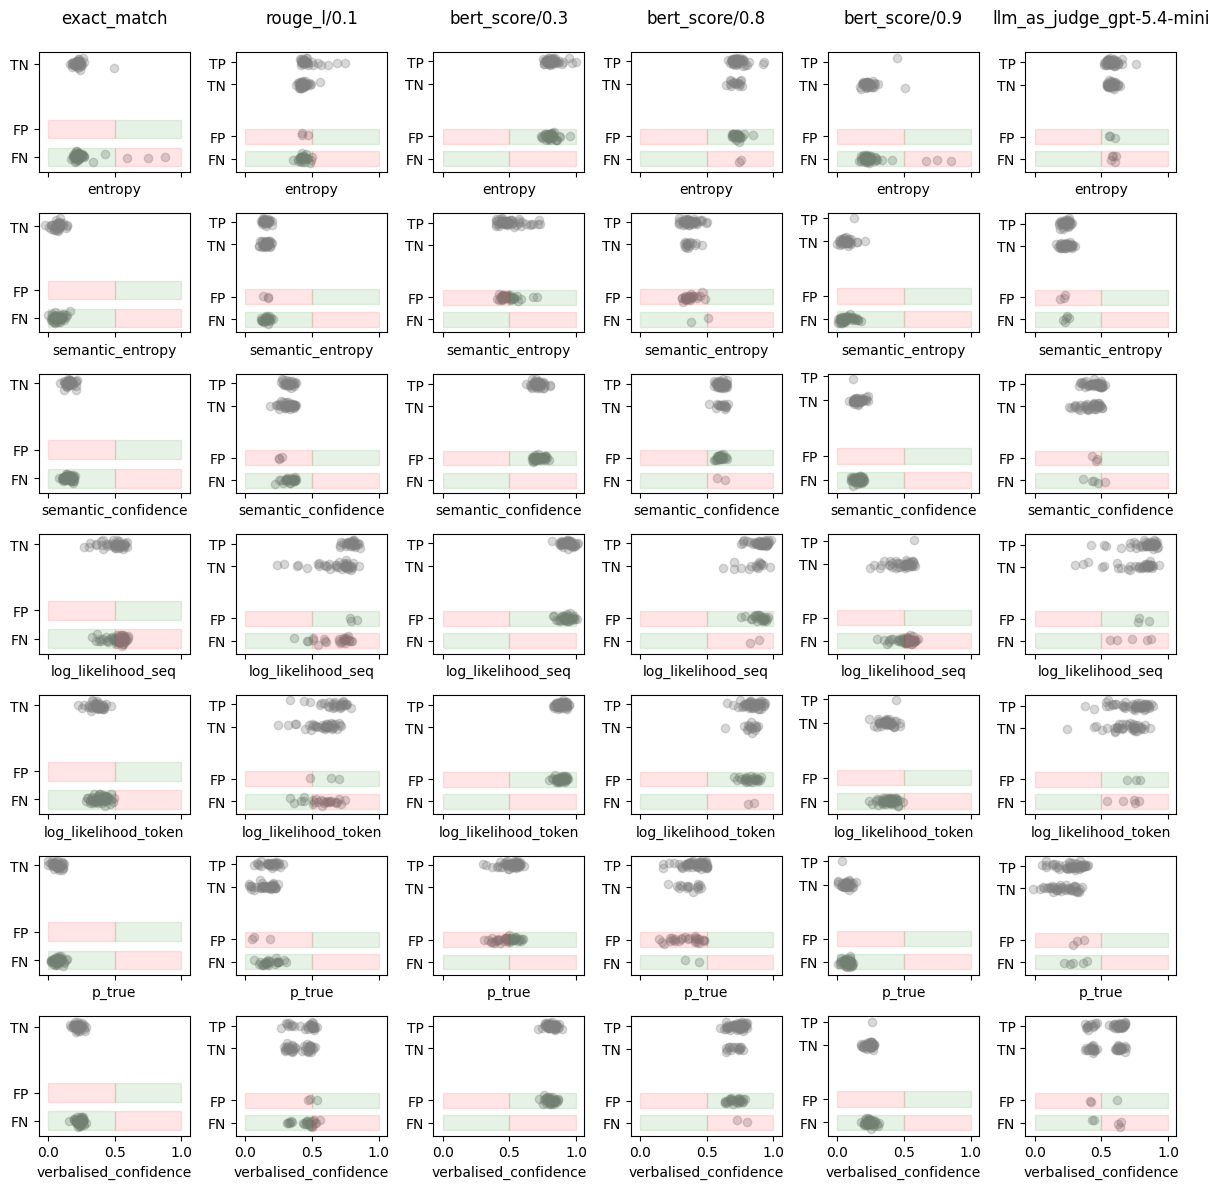

In [37]:
# num_judges - 1 because we don't plot the oracle
fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id)-1, sharex=True, figsize=(12,12))

for sys_id, sys_name in enumerate(ds.sys2id.objects):
    
    sub = joined[joined["system"] == sys_id]
    
    for j_id, j_name in enumerate(ds.judge2id.objects):
        col = j_id
        if j_id == oracle_judge:
            continue
        if j_id > oracle_judge: # adjust col number to leave the oracle out
            col = j_id - 1
                    
        sj = sub[sub["judge"] == j_id]
        axs[sys_id, col].scatter(
            sj["score"] + np.random.normal(0., 0.025, size=sj["score"].size), # some normal jitter
            sj["agree"]+0.3*sj["label"]+np.random.normal(0., 0.025, size=sj["score"].size), # I shift the TP up by +0.3; and add some normal jitter
            alpha=0.3,
            color='gray',
            label=f"judge {ds.judge2id[j_id]}",
        )
        
        axs[sys_id, col].set_xlabel(sys_name) #
        axs[0, col].set_title(f"{j_name}\n")
        axs[sys_id, col].set_yticks([0, 0.3, 1, 1.3], ["FN", "FP", "TN", "TP"])
        
        axs[sys_id, col].fill_between(np.linspace(0., 0.5), -0.1, 0.1, color='green', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0.5, 1.), -0.1, 0.1, color='red', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0., 0.5), 0.2, 0.4, color='red', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0.5, 1.), 0.2, 0.4, color='green', alpha=0.1)


fig.tight_layout(h_pad=1, w_pad=1)